In [2]:
# =========================================================
# NOTEBOOK: 06_churn_prediction.ipynb
# =========================================================


# =========================================================
# STEP 1 — IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pip
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

import shap

import joblib

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

import sys
from pathlib import Path

# =========================================================
# ADD PROJECT ROOT TO PYTHON PATH
# =========================================================

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

print("Libraries Imported Successfully")

c:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform
Libraries Imported Successfully


In [3]:
# =========================================================
# STEP 2 — LOAD DATASET
# =========================================================

master_df = pd.read_csv(
    r'C:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform\data\processed\statistical_analysis_dataset.csv'
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
# =========================================================
# STEP 3 — DATASET OVERVIEW
# =========================================================

print("\nDataset Shape:")
print(master_df.shape)

print("\nDataset Sample:\n")

display(master_df.head())


Dataset Shape:
(2530433, 87)

Dataset Sample:



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration_days,delivery_delay_days,approval_time_hours,purchase_month,purchase_year,purchase_weekday,customer_unique_id,customer_gender,customer_age,customer_zip_code_prefix,customer_city,customer_state,customer_segment,order_item_id,product_id,seller_id,shipping_limit_date,price_x,freight_value,discount_rate,product_category_name,product_name,product_brand,product_weight_g,product_length_cm,product_height_cm,product_width_cm,cost,price_y,seller_contact_gender,seller_contact_age,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_creation_date,review_answer_timestamp,purchase_day,purchase_hour,purchase_weekend,payment_apple_pay,payment_bank_transfer,payment_boleto,payment_credit_card,payment_debit_card,payment_paypal,payment_voucher,payment_apple_pay.1,payment_bank_transfer.1,payment_boleto.1,payment_credit_card.1,payment_debit_card.1,payment_paypal.1,payment_voucher.1,review_length,review_word_count,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_delay,unique_products_purchased,Recency,Frequency,Monetary,churn,product_revenue,product_total_orders,product_avg_review,product_avg_delay,seller_total_revenue,seller_total_orders,seller_avg_review,seller_avg_delay
0,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaN,NaN,2026-01-04 08:33:20,0.037357,0.036951,-1.282531,12,2025,2,d45cdff2-5195-41e2-a0e5-6fe597e378dd,1,47,85037,Phoenix,AZ,0,1,89804d82-33a1-4558-8fa2-9b0252a2a406,36c2b043-ccf4-4d9c-a0bb-4b8d28737fd7,2025-12-30 07:07:20,916.90,45.47,0.0,4,Nova Desk - Industrial,3,24130,108,10,13,395.24,916.90,M,18,90086,Los Angeles,CA,1,5,1,0.725549,Unknown,4.0,NaN,NaN,27,7,1,False,False,False,False,False,True,False,False,False,False,False,False,True,False,-3.381258,-3.282810,7,-0.233903,-0.078063,3.222222,0.333333,12,-0.756465,0.911663,-0.233903,0,1234480.37,724,3.800000,-8.556017,6655560.54,5121,3.952081,-9.193164
1,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaN,NaN,2026-01-04 08:33:20,0.037357,0.036951,-1.282531,12,2025,2,d45cdff2-5195-41e2-a0e5-6fe597e378dd,1,47,85037,Phoenix,AZ,0,2,ac10b78c-342e-4b50-9ea9-bddde7db2e79,09936504-415b-4f90-a5b8-ad15a5be67d0,2025-12-30 07:07:20,817.14,172.48,0.0,2,Vertex Smartwatch S468,6,586,28,19,23,717.81,817.14,M,70,19137,Philadelphia,PA,1,5,1,0.725549,Unknown,4.0,NaN,NaN,27,7,1,False,False,False,False,False,True,False,False,False,False,False,False,True,False,-3.381258,-3.282810,7,-0.233903,-0.078063,3.222222,0.333333,12,-0.756465,0.911663,-0.233903,0,4597968.11,2719,3.779849,-16.312730,6574599.35,4999,3.996998,-18.445178
2,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaN,NaN,2026-01-04 08:33:20,0.037357,0.036951,-1.282531,12,2025,2,d45cdff2-5195-41e2-a0e5-6fe597e378dd,1,47,85037,Phoenix,AZ,0,3,f18e6310-0e75-4b7f-bc20-90ac1e7bd466,7d336012-7101-4a66-b6bc-c269620d8df9,2025-12-30 07:07:20,37.04,94.98,0.0,3,Crest Minimal Dress,1,697,55,7,7,9.68,37.04,F,27,98129,Seattle,WA,1,5,1,0.725549,Unknown,4.0,NaN,NaN,27,7,1,False,False,False,False,False,True,False,False,False,False,False,False,True,False,-3.381258,-3.282810,7,-0.233903,-0.078063,3.222222,0.333333,12,-0.756465,0.911663,-0.233903,0,1801075.20,2017,4.059165,-3.545635,6634183.36,4946,3.950022,-18.226289
3,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,0.033655,0.036951,1.601462,6,2019,0,35cee471-325e-4ad2-8e4e-7b169dc6df81,1,18,90060,Los Angeles,CA,0,1,5816f107-b725-4c41-b794-298bf9669a41,91fe2cc8-51a5


================ CHURN DISTRIBUTION ================

churn
1    1536985
0     993448
Name: count, dtype: int64


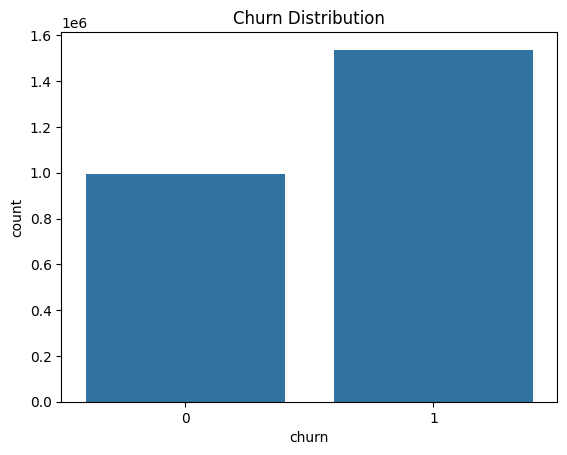

In [5]:
# =========================================================
# STEP 4 — TARGET VARIABLE CHECK
# =========================================================

print("\n================ CHURN DISTRIBUTION ================\n")

print(master_df['churn'].value_counts())

sns.countplot(
    x='churn',
    data=master_df
)

plt.title("Churn Distribution")

plt.show()

In [34]:
# =========================================================
# STEP 5 — CUSTOMER-LEVEL DATASET CREATION
# =========================================================

# ---------------------------------------------------------
# REMOVE DUPLICATE CUSTOMERS
# ---------------------------------------------------------

customer_df = ( master_df.sort_values('order_purchase_timestamp')
               .groupby('customer_unique_id')
               .last()
               .reset_index())

print("\nCustomer-Level Dataset Shape:")
print(customer_df.shape)


# =========================================================
# REMOVE LEAKAGE FEATURES
# =========================================================

leakage_cols = [

    # DIRECT CHURN LEAKAGE
    'Recency',

    # HIGH RISK POST-BEHAVIOR FEATURES
    'delivery_delay_days',
    'delivery_duration_days',
    'avg_delivery_delay',

    # IDs
    'customer_id',
    'customer_unique_id',
    'order_id',
    'product_id',
    'seller_id',
    'review_id',

    # DATES
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp',
    'purchase_year',
    'purchase_month',
    'purchase_day',
    'purchase_hour',
    'purchase_weekday',

    #(LEAKY- found from correlation analysis)
    'order_status',
    'review_length',
    'review_word_count',
    'product_avg_review',
    'product_avg_delay',
    'payment_type',
    

    #additional_leakage

    'review_length',
    'review_word_count',

    'product_avg_review',
    'product_avg_delay',

    'avg_review_score',

    'seller_avg_review',
    'seller_avg_delay',

    'product_category_name',
    'discount_rate',
    'order_item_id'
]

duplicate_cols = [col for col in customer_df.columns 
                  if col.endswith('1')]

X = customer_df.drop( columns=leakage_cols + duplicate_cols + ['churn'],
                     errors='ignore')

y = customer_df['churn']


# =========================================================
# REMOVE DUPLICATE COLUMNS
# =========================================================

X = X.loc[:, ~X.columns.duplicated()]


# =========================================================
# HANDLE CATEGORICAL FEATURES SAFELY
# =========================================================

cat_cols = X.select_dtypes(include='object').columns

# Keep only low-cardinality categorical columns
safe_cat_cols = [col for col in cat_cols
                 if X[col].nunique() <= 20]

print("\nSafe Categorical Columns:")
print(safe_cat_cols)


# One-hot encode only safe columns
X = pd.get_dummies(X, columns=safe_cat_cols, drop_first=True)


# Remove remaining object columns
X = X.select_dtypes(exclude='object')

# =========================================================
# CLEAN COLUMN NAMES
# =========================================================

X.columns = ( X.columns.str.replace(' ', '_').str.replace('[^A-Za-z0-9_]', '', regex=True))


print("\nFeature Matrix Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)


Customer-Level Dataset Shape:
(279199, 87)

Safe Categorical Columns:
['customer_city', 'customer_state', 'seller_contact_gender', 'seller_city', 'seller_state']

Feature Matrix Shape:
(279199, 75)

Target Shape:
(279199,)


In [35]:
corr_check = X.corrwith(y).sort_values(
    ascending=False
)

print(corr_check.head(20))

product_length_cm             0.037907
product_height_cm             0.019997
review_score                  0.019888
payment_boleto                0.019101
payment_voucher               0.012038
payment_debit_card            0.010058
product_weight_g              0.008882
product_width_cm              0.007872
payment_bank_transfer         0.006006
customer_city_Philadelphia    0.002393
customer_state_PA             0.002393
seller_city_Los_Angeles       0.002021
seller_state_CA               0.002021
seller_total_orders           0.001931
customer_state_IL             0.001623
customer_city_Chicago         0.001623
seller_city_Miami             0.001564
seller_state_FL               0.001564
payment_sequential            0.001542
approval_time_hours           0.001421
dtype: float64


In [36]:
for col in X.columns:

    unique_pairs = pd.crosstab( X[col], y )

    if unique_pairs.shape[0] < 10:
        print(col)
        print(unique_pairs)

customer_gender
churn                0       1
customer_gender               
0                55999  125654
1                30157   67389
customer_segment
churn                 0       1
customer_segment               
0                 60378  135453
1                 17135   38422
2                  8643   19168
product_brand
churn              0      1
product_brand              
0              10421  23048
1              10803  24353
2              10305  24048
3              11253  25187
4              11217  24372
5               9763  23290
6              11585  24411
7              10809  24334
payment_sequential
churn                   0       1
payment_sequential               
1                   79786  178601
2                    6370   14442
review_score
churn             0      1
review_score              
1.0            2894   9221
2.0            9739  21969
3.0            6702  12732
4.0           32621  56551
5.0           34200  92570
purchase_weekend
churn          

In [37]:
# =========================================================
# STEP 6 — TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

print("\nTrain Test Split Completed")

print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")


Train Test Split Completed
X_train Shape : (223359, 75)
X_test Shape  : (55840, 75)


In [38]:
# =========================================================
# STEP 7 — BASELINE MODEL
# =========================================================

# =========================================================
# FEATURE SCALING (ONLY FOR LOGISTIC)
# =========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

# ---------------------------------------------------------
# LOGISTIC REGRESSION
# ---------------------------------------------------------

log_model = LogisticRegression(solver='saga', 
                               max_iter=300,
                               n_jobs=-1)

log_model.fit( X_train_scaled, y_train)

log_preds = log_model.predict( X_test_scaled)

log_probs = log_model.predict_proba( X_test_scaled )[:,1]

print("\nLogistic Regression Trained")

Feature Scaling Completed

Logistic Regression Trained


In [39]:
# =========================================================
# STEP 8 — DECISION TREE
# =========================================================

dt_model = DecisionTreeClassifier( max_depth=10, random_state=42)

dt_model.fit( X_train, y_train)

dt_preds = dt_model.predict(X_test)

dt_probs = dt_model.predict_proba( X_test )[:,1]

print("Decision Tree Trained")

Decision Tree Trained


In [40]:
# =========================================================
# STEP 9 — RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(n_estimators=200, 
                                  max_depth=15, 
                                  random_state=42, 
                                  n_jobs=-1)

rf_model.fit( X_train,y_train)

rf_preds = rf_model.predict(X_test)

rf_probs = rf_model.predict_proba( X_test )[:,1]

print("Random Forest Trained")

Random Forest Trained


In [41]:

# =========================================================
# STEP 10 — XGBOOST
# =========================================================

xgb_model = XGBClassifier( n_estimators=200, 
                          learning_rate=0.1, 
                          max_depth=8, 
                          random_state=42, 
                          eval_metric='logloss')

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_probs = xgb_model.predict_proba( X_test )[:,1]

print("XGBoost Trained")

XGBoost Trained


In [42]:
# =========================================================
# STEP 11 — LIGHTGBM
# =========================================================

lgbm_model = LGBMClassifier(n_estimators=200,
                            learning_rate=0.1,
                            max_depth=8,
                            random_state=42)

lgbm_model.fit(X_train, y_train)

lgbm_preds = lgbm_model.predict(X_test)

lgbm_probs = lgbm_model.predict_proba( X_test )[:,1]

print("LightGBM Trained")

[LightGBM] [Info] Number of positive: 154434, number of negative: 68925
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016067 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4618
[LightGBM] [Info] Number of data points in the train set: 223359, number of used features: 75
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.691416 -> initscore=0.806748
[LightGBM] [Info] Start training from score 0.806748
LightGBM Trained


In [43]:
# =========================================================
# STEP 12 — CATBOOST
# =========================================================

cat_model = CatBoostClassifier(iterations=200, 
                               learning_rate=0.1, 
                               depth=8, 
                               verbose=0,
                               random_state=42)

cat_model.fit(X_train, y_train)

cat_preds = cat_model.predict(X_test)

cat_probs = cat_model.predict_proba( X_test )[:,1]

print("CatBoost Trained")

CatBoost Trained


In [44]:
# =========================================================
# STEP 13 — EVALUATION FUNCTION
# =========================================================

def evaluate_model(y_true, y_pred, y_probs, model_name):

    accuracy = accuracy_score( y_true, y_pred)

    precision = precision_score( y_true, y_pred)

    recall = recall_score(y_true, y_pred)

    f1 = f1_score( y_true, y_pred)

    roc_auc = roc_auc_score(y_true, y_probs)

    print("\n===================================================")
    print(f"{model_name} PERFORMANCE")
    print("===================================================")

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    print("\nClassification Report:\n")

    print(classification_report( y_true, y_pred))

In [45]:
# =========================================================
# STEP 14 — MODEL EVALUATION
# =========================================================

evaluate_model( y_test, log_preds, log_probs, "Logistic Regression")

evaluate_model( y_test, dt_preds, dt_probs, "Decision Tree" )

evaluate_model( y_test, rf_preds, rf_probs, "Random Forest" )

evaluate_model( y_test, xgb_preds, xgb_probs, "XGBoost")

evaluate_model(y_test, lgbm_preds, lgbm_probs, "LightGBM")

evaluate_model(  y_test, cat_preds, cat_probs, "CatBoost")


Logistic Regression PERFORMANCE
Accuracy  : 0.7292
Precision : 0.7475
Recall    : 0.9185
F1 Score  : 0.8243
ROC AUC   : 0.7306

Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.30      0.41     17231
           1       0.75      0.92      0.82     38609

    accuracy                           0.73     55840
   macro avg       0.69      0.61      0.62     55840
weighted avg       0.71      0.73      0.70     55840


Decision Tree PERFORMANCE
Accuracy  : 0.7296
Precision : 0.7556
Recall    : 0.9001
F1 Score  : 0.8215
ROC AUC   : 0.7296

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.35      0.44     17231
           1       0.76      0.90      0.82     38609

    accuracy                           0.73     55840
   macro avg       0.68      0.62      0.63     55840
weighted avg       0.71      0.73      0.70     55840


Random Forest PERFORMANCE
Accuracy  : 0.7335


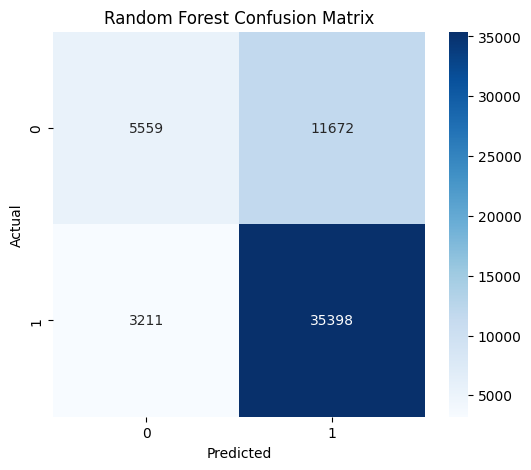

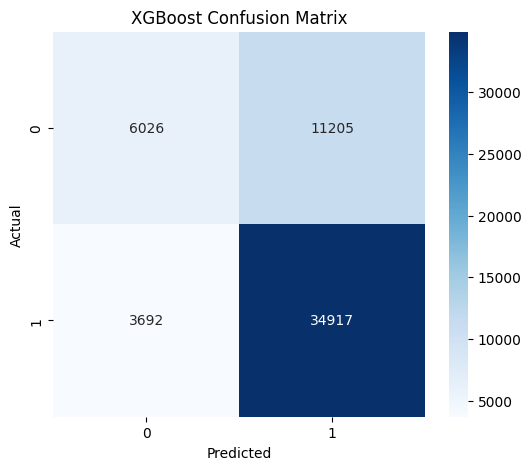

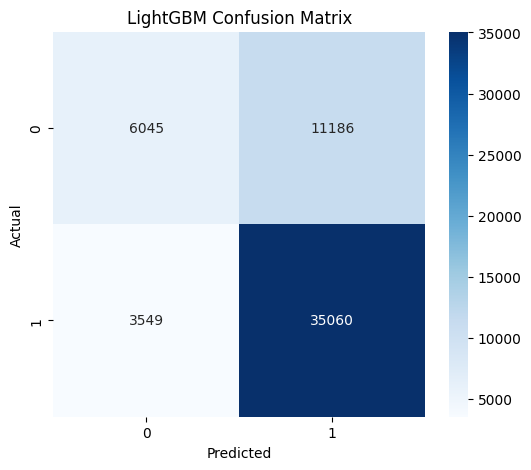

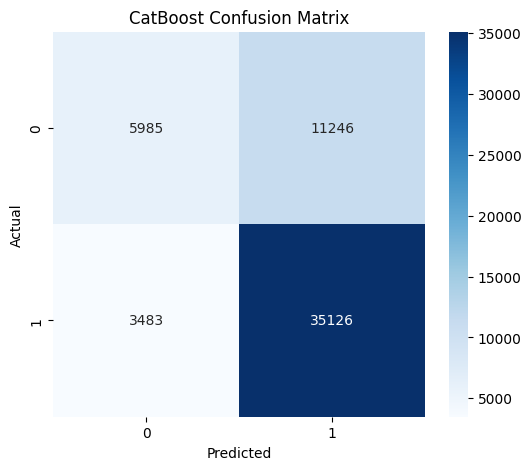

In [46]:
# =========================================================
# STEP 15 — CONFUSION MATRIX
# =========================================================

models_preds = { 'Random Forest': rf_preds,
                 'XGBoost': xgb_preds,
                 'LightGBM': lgbm_preds,
                 'CatBoost': cat_preds}

for model_name, preds in models_preds.items():

    cm = confusion_matrix( y_test, preds )

    plt.figure(figsize=(6,5))

    sns.heatmap( cm, annot=True, fmt='d', cmap='Blues' )

    plt.title(f"{model_name} Confusion Matrix")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [48]:
# =========================================================
# STEP 16 — CROSS VALIDATION
# =========================================================

print("\n================ CROSS VALIDATION ON ALL MODELS ================\n")

models = {'Logistic': log_model,
          'RF': rf_model,  
          'XGB': xgb_model,
          'LGBM': lgbm_model}

for name, model in models.items():

    scores = cross_val_score( model, X, y, cv=5, scoring='roc_auc', n_jobs=-1 )

    print(name)
    print(scores.mean())


================ CROSS VALIDATION ON ALL MODELS ================

Logistic
0.6002731204988618
RF
0.73693650743826
XGB
0.7372363956195701
LGBM
0.7431721715089343


In [51]:
# =========================================================
# STEP 17 — HYPERPARAMETER TUNING
# =========================================================

print("\n================ HYPERPARAMETER TUNING ================\n")

param_grid = { 'n_estimators': [100, 200], 
               'learning_rate': [0.05, 0.1],
               'max_depth': [5, 8],
               'subsample': [0.8, 1.0] }

grid_search = GridSearchCV( LGBMClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
                             param_grid,
                             cv=3,
                             scoring='f1',
                             n_jobs=-1,
                             verbose=1)

grid_search.fit( X_train, y_train )

best_lgbm_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)


================ HYPERPARAMETER TUNING ================

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Info] Number of positive: 154434, number of negative: 68925
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037831 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4618
[LightGBM] [Info] Number of data points in the train set: 223359, number of used features: 75
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}


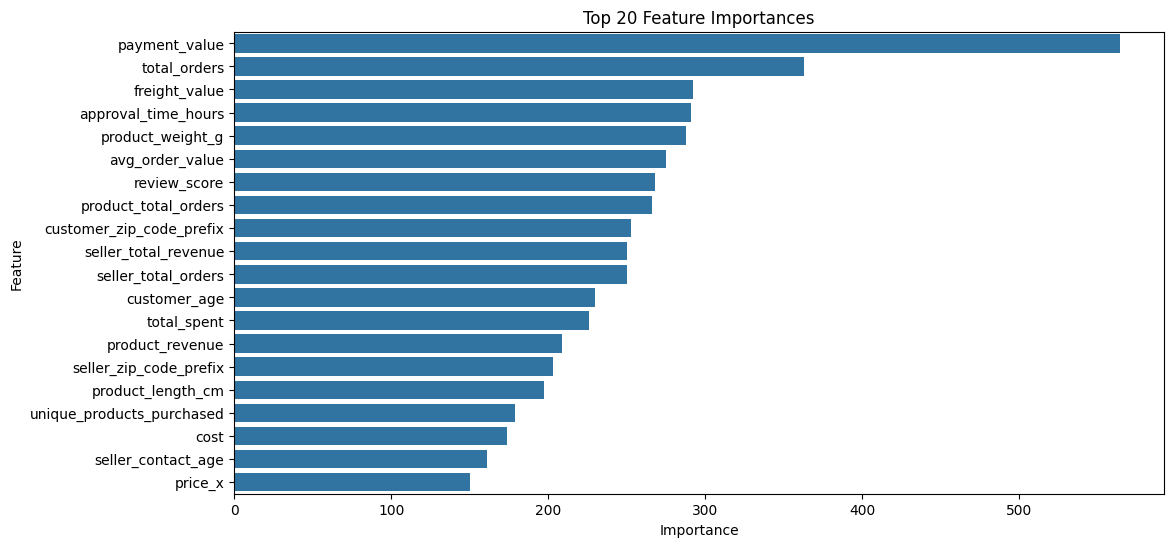

In [52]:
# =========================================================
# STEP 18 — FEATURE IMPORTANCE
# =========================================================

feature_importance = pd.DataFrame({'Feature': X.columns, 
                                   'Importance': best_lgbm_model.feature_importances_})

feature_importance = ( feature_importance.sort_values( by='Importance',
                                                       ascending=False ).head(20))

plt.figure(figsize=(12,6))

sns.barplot( x='Importance', y='Feature', data=feature_importance )

plt.title("Top 20 Feature Importances")

plt.show()


================ SHAP ANALYSIS ================



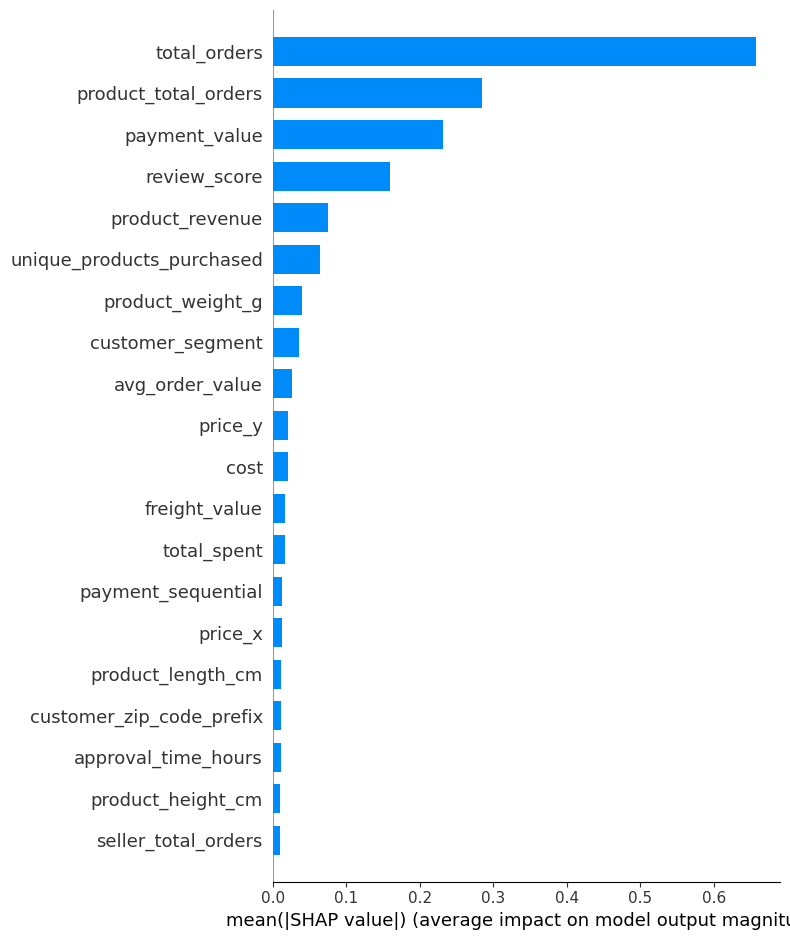

In [59]:
# =========================================================
# STEP 19 — SHAP EXPLAINABILITY
# =========================================================

print("\n================ SHAP ANALYSIS ================\n")

explainer = shap.TreeExplainer( best_lgbm_model )

sample_X = X_test.sample(2000, random_state=42)

shap_values = explainer.shap_values( sample_X )

plt.figure(figsize=(10,5))

shap.summary_plot( shap_values, sample_X, plot_type='bar')


ROC-AUC Score:
0.7446


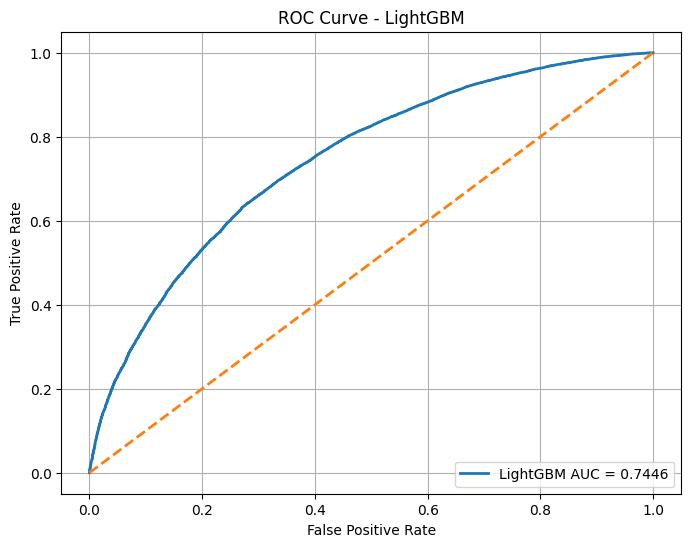

In [60]:
# =========================================================
# STEP 20 — ROC-AUC CURVE
# =========================================================

# ---------------------------------------------------------
# PREDICT PROBABILITIES
# ---------------------------------------------------------

lgbm_probs = best_lgbm_model.predict_proba( X_test )[:,1]

# ---------------------------------------------------------
# CALCULATE ROC CURVE
# ---------------------------------------------------------

fpr, tpr, thresholds = roc_curve( y_test, lgbm_probs )

# ---------------------------------------------------------
# CALCULATE ROC-AUC SCORE
# ---------------------------------------------------------

auc_score = roc_auc_score( y_test, lgbm_probs)

print("\nROC-AUC Score:")

print(f"{auc_score:.4f}")

# ---------------------------------------------------------
# PLOT ROC CURVE
# ---------------------------------------------------------

plt.figure(figsize=(8,6))

plt.plot( fpr, 
          tpr, 
          linewidth=2,
          label=f'LightGBM AUC = {auc_score:.4f}')

# Random baseline
plt.plot( [0,1], [0,1], 
          linestyle='--',
          linewidth=2 )

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - LightGBM")

plt.legend(loc='lower right')

plt.grid(True)

plt.show()

In [4]:
# =========================================================
# STEP 21 — SAVE BEST MODEL
# =========================================================

from src.utils.path_config import MODELS_DIR

joblib.dump(
    best_lgbm_model,
    MODELS_DIR / "churn_model.pkl"
)

print("Churn Model Saved Successfully")

NameError: name 'best_lgbm_model' is not defined

In [ ]:
# =========================================================
# STEP 22 — SAVE FEATURE COLUMNS
# =========================================================

joblib.dump(
    X.columns.tolist(),
    MODELS_DIR / "churn_features.pkl"
)

print("Feature Columns Saved Successfully")

Feature Columns Saved Successfully


In [64]:
# =========================================================
# STEP 23 — BUSINESS INTERPRETATION
# =========================================================

print("\n===================================================")
print("BUSINESS INSIGHTS")
print("===================================================")

print("""

1. Built customer churn prediction pipeline.

2. Compared:
   - Logistic Regression
   - Decision Tree
   - Random Forest
   - XGBoost
   - LightGBM
   - CatBoost

3. Evaluated models using:
   - Accuracy
   - Precision
   - Recall
   - F1 Score
   - ROC-AUC

4. Performed:
   - Cross Validation
   - Hyperparameter Tuning

5. Identified important churn-driving features.

6. Applied SHAP explainability for model transparency.

7. Created production-ready saved model artifacts.

""")


BUSINESS INSIGHTS


1. Built customer churn prediction pipeline.

2. Compared:
   - Logistic Regression
   - Decision Tree
   - Random Forest
   - XGBoost
   - LightGBM
   - CatBoost

3. Evaluated models using:
   - Accuracy
   - Precision
   - Recall
   - F1 Score
   - ROC-AUC

4. Performed:
   - Cross Validation
   - Hyperparameter Tuning

5. Identified important churn-driving features.

6. Applied SHAP explainability for model transparency.

7. Created production-ready saved model artifacts.




In [65]:
# =========================================================
# STEP 24 — NOTEBOOK COMPLETION
# =========================================================

print("\n===================================================")
print("06_churn_prediction.ipynb COMPLETED SUCCESSFULLY")
print("===================================================")


06_churn_prediction.ipynb COMPLETED SUCCESSFULLY
